In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier



df = pd.read_csv("diabetes (1).csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies            

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


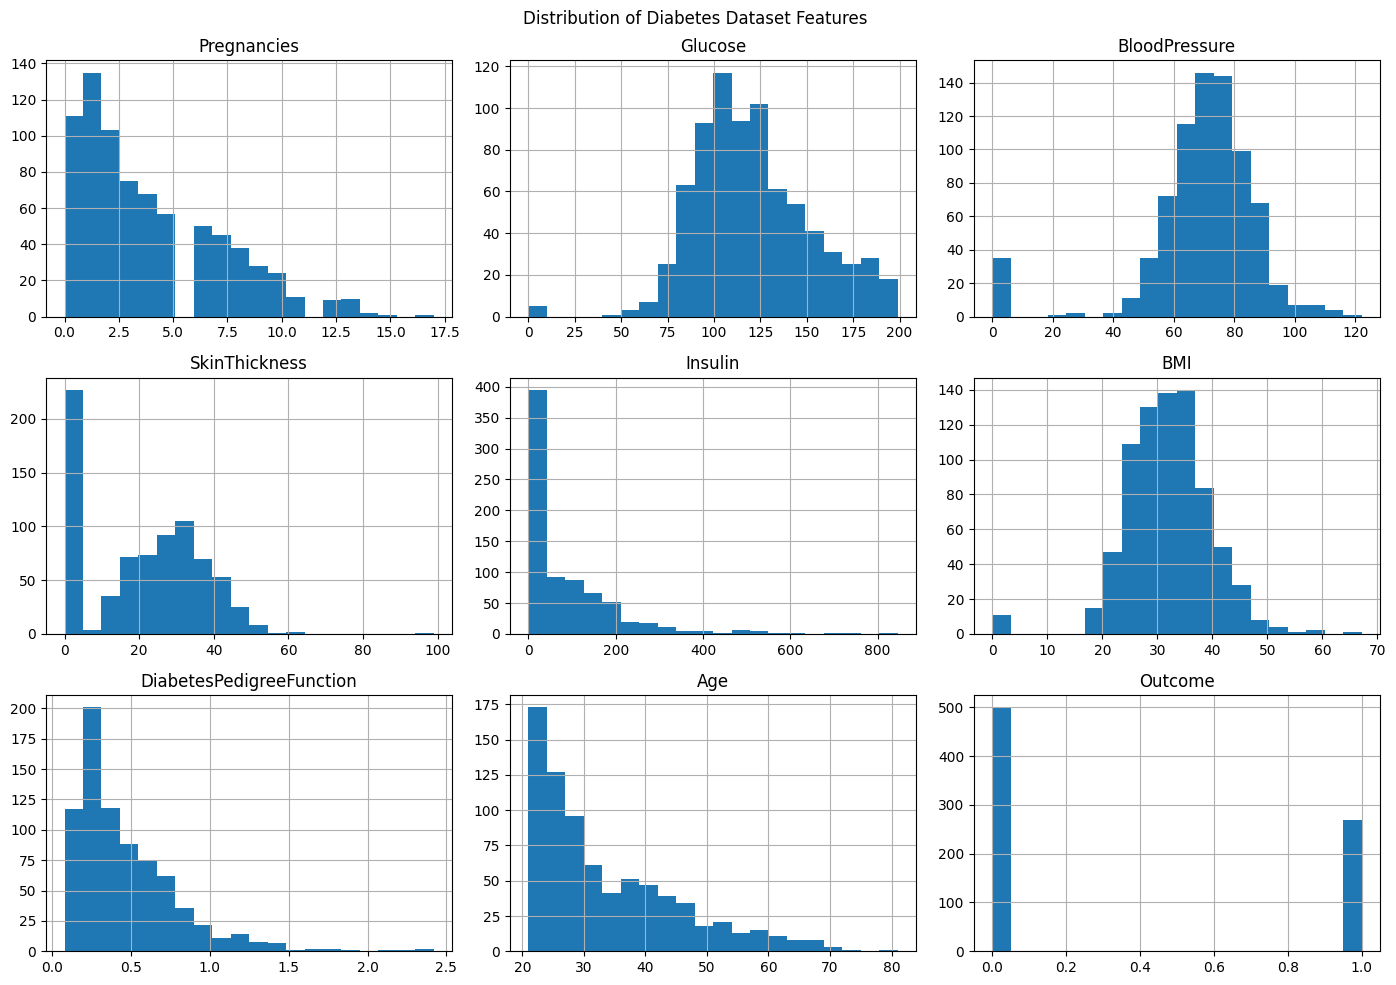

In [23]:
#Missing Values
print("Missing values:")
print(df.isnull().sum())

print("\nZero values:")
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print(
    (df[zero_columns] == 0).sum()
)

#task-1
df.hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Diabetes Dataset Features"
)

plt.tight_layout()
plt.show()

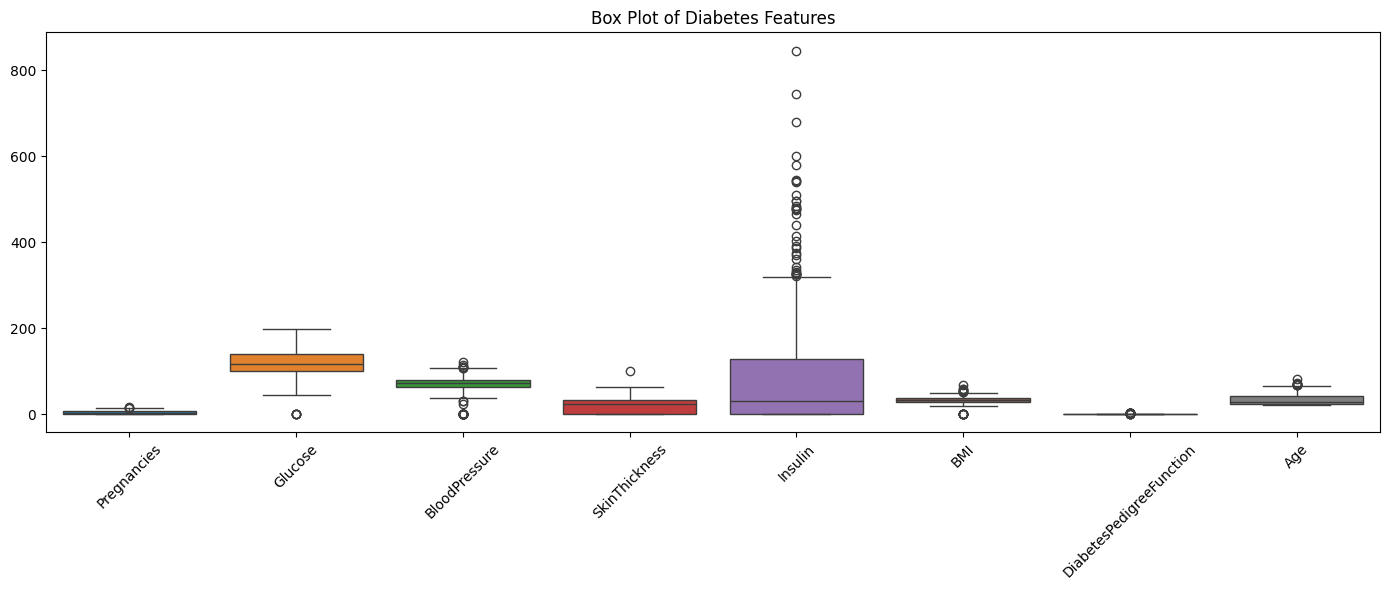

In [24]:
#Box Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df.drop(columns=['Outcome'])
)

plt.title("Box Plot of Diabetes Features")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

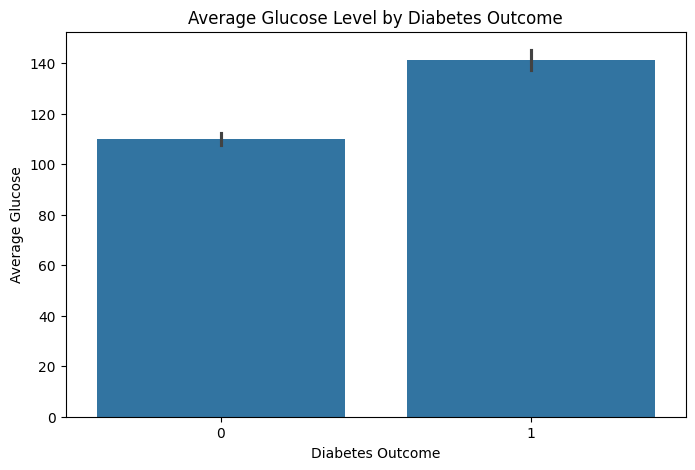

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Outcome',
    y='Glucose'
)

plt.title("Average Glucose Level by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Average Glucose")

plt.show()

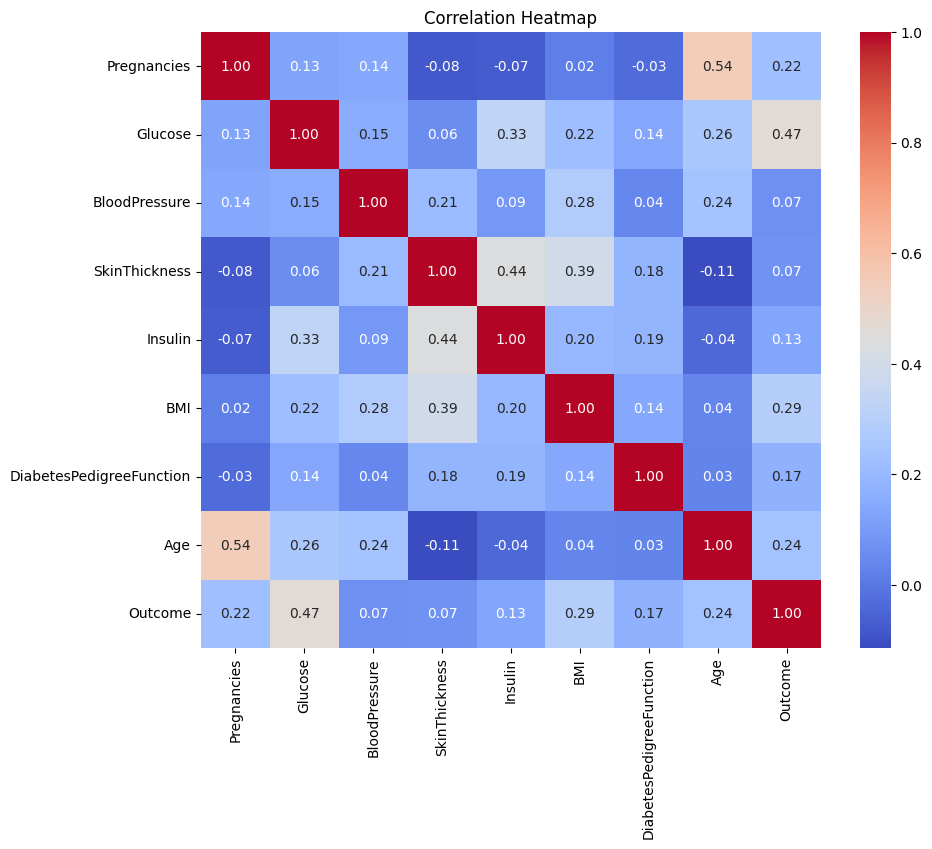

In [26]:
#Correlation
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Initial Observations

The visualizations show that Glucose has a relatively strong relationship with
the diabetes outcome compared with many other variables.

BMI, Age, and Diabetes Pedigree Function also show relationships with the
target. The correlation heatmap helps identify relationships between the
predictor variables and possible multicollinearity.

In [28]:
#Task-2
df_clean = df.copy()

zero_as_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for column in zero_as_missing:
    df_clean[column] = df_clean[column].replace(
        0,
        np.nan
    )

print("Missing values after converting invalid zeros:")
print(df_clean.isnull().sum())

for column in zero_as_missing:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("\nMissing values after median imputation:")
print(df_clean.isnull().sum())

Missing values after converting invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [30]:
X = df_clean.drop(
    columns=['Outcome']
)

y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

Training Shape: (614, 8)
Testing Shape: (154, 8)
Feature scaling completed.


In [32]:
#LGBM model
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train_scaled,
    y_train
)

lgbm_pred = lgbm_model.predict(
    X_test_scaled
)

lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

lgbm_precision = precision_score(
    y_test,
    lgbm_pred
)

lgbm_recall = recall_score(
    y_test,
    lgbm_pred
)

lgbm_f1 = f1_score(
    y_test,
    lgbm_pred
)

print("LightGBM Results")
print("----------------")
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lgbm_pred
    )
)

LightGBM Results
----------------
Accuracy : 0.7727272727272727
Precision: 0.7021276595744681
Recall   : 0.6111111111111112
F1 Score : 0.6534653465346535

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
#XGboost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test_scaled
)

#Evaluate
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

print("XGBoost Results")
print("----------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

XGBoost Results
----------------
Accuracy : 0.7532467532467533
Precision: 0.6739130434782609
Recall   : 0.5740740740740741
F1 Score : 0.62

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [35]:
#Cross validation and hypertuning
lgbm_cv = cross_val_score(
    lgbm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

xgb_cv = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("LightGBM Cross-Validation F1 Scores:")
print(lgbm_cv)

print("\nLightGBM Mean F1:",
      lgbm_cv.mean())

print("\nXGBoost Cross-Validation F1 Scores:")
print(xgb_cv)

print("\nXGBoost Mean F1:",
      xgb_cv.mean())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Cross-Validation F1 Scores:
[0.59770115 0.68292683 0.58823529 0.61971831 0.6744186 ]

LightGBM Mean F1: 0.6326000374643089

XGBoost Cross-Validation F1 Scores:
[0.54320988 0.64197531 0.65116279 0.61111111 0.65882353]

XGBoost Mean F1: 0.621256523281147


In [36]:
#XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(
    X_train_scaled,
    y_train
)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [38]:
lgbm_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    lgbm_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

lgbm_grid.fit(
    X_train_scaled,
    y_train
)

print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)

Best LightGBM Parameters:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


In [40]:
#Comprasion
comparison = pd.DataFrame({
    'Model': [
        'LightGBM',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(
            y_test,
            lgbm_grid.predict(X_test_scaled)
        ),
        accuracy_score(
            y_test,
            xgb_grid.predict(X_test_scaled)
        )
    ],

    'Precision': [
        precision_score(
            y_test,
            lgbm_grid.predict(X_test_scaled)
        ),
        precision_score(
            y_test,
            xgb_grid.predict(X_test_scaled)
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            lgbm_grid.predict(X_test_scaled)
        ),
        recall_score(
            y_test,
            xgb_grid.predict(X_test_scaled)
        )
    ],

    'F1 Score': [
        f1_score(
            y_test,
            lgbm_grid.predict(X_test_scaled)
        ),
        f1_score(
            y_test,
            xgb_grid.predict(X_test_scaled)
        )
    ]
})

print(comparison)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.766234     0.6875  0.611111  0.647059
1   XGBoost  0.740260     0.6400  0.592593  0.615385


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


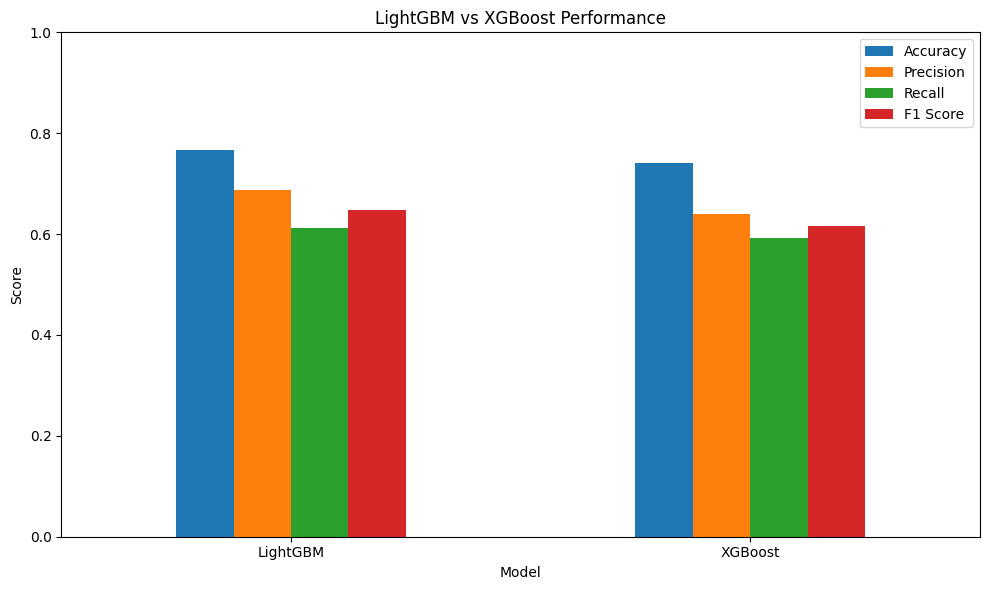

In [41]:
#Visualization
comparison.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    "LightGBM vs XGBoost Performance"
)

plt.ylabel("Score")
plt.xticks(rotation=0)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# **Final Conclusion**
The Diabetes dataset was analyzed using Exploratory Data Analysis techniques
including statistical summaries, histograms, box plots, bar plots, and a
correlation heatmap.

Although the dataset did not contain explicit missing values, zero values in
medical measurements such as Glucose, BloodPressure, SkinThickness, Insulin,
and BMI were treated as missing values because zero is not a realistic
measurement for these variables. Median imputation was then applied.

The dataset contains only numerical predictor variables, so categorical
encoding was not required.

The data was divided into training and testing sets using an 80:20 split.
LightGBM and XGBoost classification models were then trained and evaluated
using accuracy, precision, recall, and F1-score.

Five-fold cross-validation was used to obtain a more reliable estimate of
model performance. GridSearchCV was also used to tune important model
hyperparameters such as the number of estimators, learning rate, and maximum
tree depth.

The final comparison shows the performance differences between LightGBM and
XGBoost. The model with the stronger evaluation metrics can be selected for
further diabetes prediction tasks.

### Practical Implications

Both LightGBM and XGBoost are powerful gradient boosting algorithms and can
capture nonlinear relationships between medical variables and diabetes
outcomes.

In a real-world healthcare application, model selection should not be based
only on accuracy. Recall is particularly important because failing to identify
a patient who actually has diabetes may have serious consequences.

The final model should therefore be selected by considering the business or
medical objective, model performance, interpretability, and validation results.